In [101]:
# !pip install torch torchvision torchaudio
# !pip install pandas matplotlib pillow scikit-learn

In [102]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torchvision import transforms, models

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

DEVICE = torch.device("cpu")
print("Using device:", DEVICE)

Using device: cpu


In [103]:
MODEL_PATH = Path("traffic_sign_model.pth")

if not MODEL_PATH.exists():
    raise FileNotFoundError(
        "Could not find traffic_sign_model.pth. "
    )

try:
    checkpoint = torch.load(MODEL_PATH, map_location=DEVICE, weights_only=False)
except TypeError:
    checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)

print("Checkpoint keys:", list(checkpoint.keys()))

Checkpoint keys: ['model_state_dict', 'class_id_to_idx', 'idx_to_class_id', 'idx_to_name', 'num_classes']


In [104]:
NUM_CLASSES = checkpoint["num_classes"]

class_id_to_idx = checkpoint.get("class_id_to_idx", None)
idx_to_class_id = checkpoint.get("idx_to_class_id", None)
idx_to_name = checkpoint.get("idx_to_name", None)

if class_id_to_idx is not None:
    class_id_to_idx = {int(k): int(v) for k, v in class_id_to_idx.items()}

if idx_to_class_id is not None:
    idx_to_class_id = {int(k): int(v) for k, v in idx_to_class_id.items()}

if idx_to_name is not None:
    idx_to_name = {int(k): str(v) for k, v in idx_to_name.items()}
else:
    idx_to_name = {i: f"Class {i}" for i in range(NUM_CLASSES)}

print("Number of model classes:", NUM_CLASSES)

mapping_df = pd.DataFrame({
    "model_index": list(range(NUM_CLASSES)),
    "original_ClassId": [idx_to_class_id.get(i, i) if idx_to_class_id else i for i in range(NUM_CLASSES)],
    "class_name": [idx_to_name.get(i, f"Class {i}") for i in range(NUM_CLASSES)]
})

mapping_df

Number of model classes: 50


,model_index,original_ClassId,class_name
0,0,0,Speed limit (5km/h)
1,1,1,Speed limit (15km/h)
2,2,2,Speed limit (30km/h)
3,3,3,Speed limit (40km/h)
4,4,4,Speed limit (50km/h)
5,5,5,Speed limit (60km/h)
6,6,6,Speed limit (70km/h)
7,7,7,speed limit (80km/h)
8,8,8,Dont Go straight or left
9,9,9,Dont Go straight or Right


In [105]:
model = models.resnet18(weights=None)

in_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.30),
    nn.Linear(in_features, NUM_CLASSES)
)

model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(DEVICE)
model.eval()

print("Model loaded successfully.")

Model loaded successfully.


In [106]:
IMG_SIZE = 224

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

demo_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

In [107]:
DEMO_IMAGE_DIR = Path("demo_images")

if not DEMO_IMAGE_DIR.exists():
    raise FileNotFoundError(
        "Could not find a folder named demo_images. "
        "Create demo_images and put your 10 collected traffic sign images inside it."
    )

image_extensions = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]

demo_image_paths = sorted([
    p for p in DEMO_IMAGE_DIR.rglob("*")
    if p.suffix.lower() in image_extensions
])

print("Number of demo images found:", len(demo_image_paths))

if len(demo_image_paths) < 10:
    print("Warning: The project requires at least 10 independent demo images.")

demo_image_paths[:10]

Number of demo images found: 10


[PosixPath('demo_images/1.png'),
 PosixPath('demo_images/10.png'),
 PosixPath('demo_images/2.png'),
 PosixPath('demo_images/3.png'),
 PosixPath('demo_images/4.png'),
 PosixPath('demo_images/5.png'),
 PosixPath('demo_images/6.png'),
 PosixPath('demo_images/7.png'),
 PosixPath('demo_images/8.png'),
 PosixPath('demo_images/9.jpg')]

In [108]:
LABELS_PATH = Path("demo_labels.csv")

if LABELS_PATH.exists():
    demo_labels_df = pd.read_csv(LABELS_PATH)
    print("Loaded demo_labels.csv")
    display(demo_labels_df.head())
else:
    starter_df = pd.DataFrame({
        "filename": [p.name for p in demo_image_paths],
        "true_class_index": [""] * len(demo_image_paths),
    })
    starter_df.to_csv(LABELS_PATH, index=False)
    demo_labels_df = None

Loaded demo_labels.csv


,filename,true_model_index
0,1.png,16
1,2.png,37
2,3.png,48
3,4.png,7
4,5.png,49


In [109]:
@torch.no_grad()
def predict_image(image_path, model, transform):
    image = Image.open(image_path).convert("RGB")
    tensor = transform(image).unsqueeze(0).to(DEVICE)

    outputs = model(tensor)
    probabilities = torch.softmax(outputs, dim=1).squeeze(0).numpy()

    predicted_idx = int(np.argmax(probabilities))
    confidence = float(probabilities[predicted_idx])

    predicted_class_id = idx_to_class_id.get(predicted_idx, predicted_idx) if idx_to_class_id else predicted_idx
    predicted_name = idx_to_name.get(predicted_idx, f"Class {predicted_idx}")

    return predicted_idx, predicted_class_id, predicted_name, confidence, probabilities

In [110]:
results = []

for image_path in demo_image_paths:
    pred_idx, pred_class_id, pred_name, confidence, probabilities = predict_image(
        image_path,
        model,
        demo_transform
    )

    results.append({
        "filename": image_path.name,
        "image_path": str(image_path),
        "predicted_model_index": pred_idx,
        "predicted_ClassId": pred_class_id,
        "predicted_name": pred_name,
        "confidence": confidence,
    })

results_df = pd.DataFrame(results)

labels_df = pd.read_csv("demo_labels.csv")

# merge labels onto prediction results
results_df = results_df.merge(labels_df, on="filename", how="left")

#
results_df["true_model_index"] = pd.to_numeric(
    results_df["true_model_index"],
    errors="coerce"
)


# Add true class name
results_df["true_name"] = results_df["true_model_index"].map(idx_to_name)

# Mark correct/wrong
results_df["correct"] = results_df["predicted_model_index"] == results_df["true_model_index"]

results_df

,filename,image_path,predicted_model_index,predicted_ClassId,predicted_name,confidence,true_model_index,true_name,correct
0,1.png,demo_images/1.png,16,16,No Car,0.999860,16,No Car,True
1,10.png,demo_images/10.png,26,26,keep Right,0.999412,26,keep Right,True
2,2.png,demo_images/2.png,37,37,Children crossing,0.646883,37,Children crossing,True
3,3.png,demo_images/3.png,48,54,No stopping,0.996755,48,No stopping,True
4,4.png,demo_images/4.png,7,7,speed limit (80km/h),0.998169,7,speed limit (80km/h),True
5,5.png,demo_images/5.png,49,55,No entry,0.814159,49,No entry,True
6,6.png,demo_images/6.png,7,7,speed limit (80km/h),0.969621,2,Speed limit (30km/h),False
7,7.png,demo_images/7.png,17,17,No horn,0.997809,17,No horn,True
8,8.png,demo_images/8.png,27,27,Roundabout mandatory,0.999993,27,Roundabout mandatory,True
9,9.jpg,demo_images/9.jpg,32,32,Road Divider,0.384395,43,Train Crossing,False


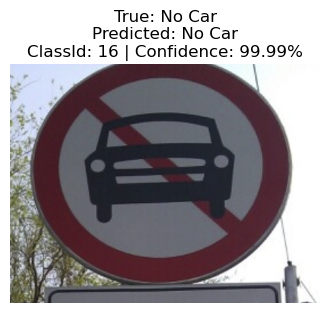

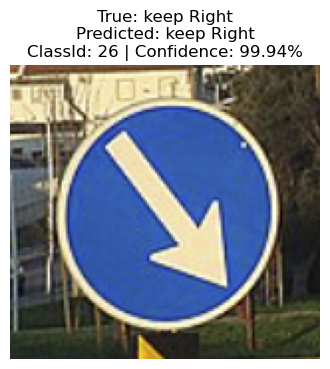

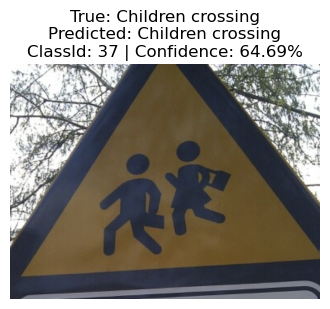

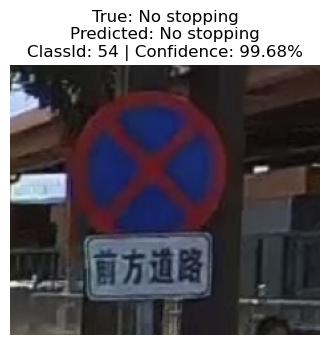

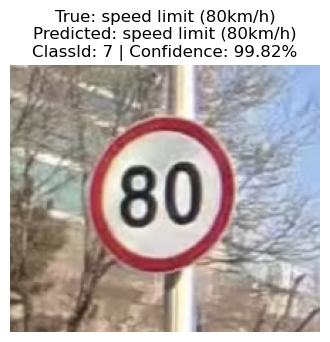

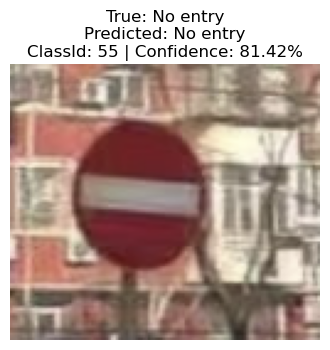

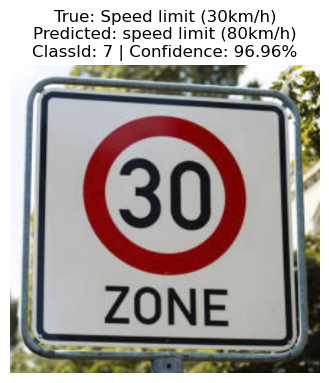

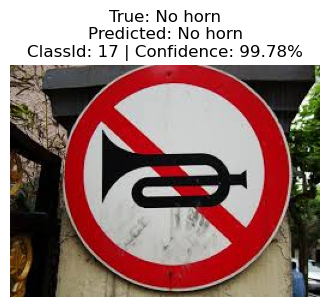

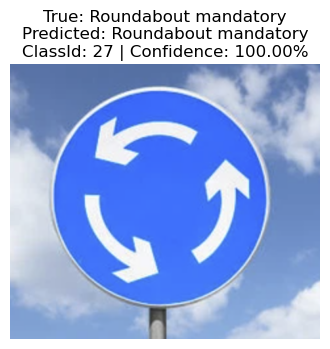

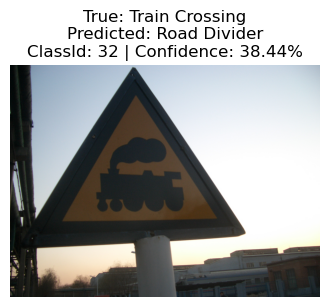

In [111]:
for _, row in results_df.iterrows():
    image = Image.open(row["image_path"]).convert("RGB")

    plt.figure(figsize=(4, 4))
    plt.imshow(image)

    title = (
        f"Predicted: {row['predicted_name']}\n"
        f"ClassId: {row['predicted_ClassId']} | Confidence: {row['confidence']:.2%}"
    )

    if "true_name" in results_df.columns and pd.notna(row.get("true_name")):
        title = f"True: {row['true_name']}\n" + title
    
    plt.title(title)
    plt.axis("off")
    plt.show()

Demo accuracy on labeled collected images: 0.8000

Classification report:
                      precision    recall  f1-score   support

Speed limit (30km/h)     0.0000    0.0000    0.0000         1
speed limit (80km/h)     0.5000    1.0000    0.6667         1
              No Car     1.0000    1.0000    1.0000         1
             No horn     1.0000    1.0000    1.0000         1
          keep Right     1.0000    1.0000    1.0000         1
Roundabout mandatory     1.0000    1.0000    1.0000         1
        Road Divider     0.0000    0.0000    0.0000         0
   Children crossing     1.0000    1.0000    1.0000         1
      Train Crossing     0.0000    0.0000    0.0000         1
         No stopping     1.0000    1.0000    1.0000         1
            No entry     1.0000    1.0000    1.0000         1

            accuracy                         0.8000        10
           macro avg     0.6818    0.7273    0.6970        10
        weighted avg     0.7500    0.8000    0.7667     

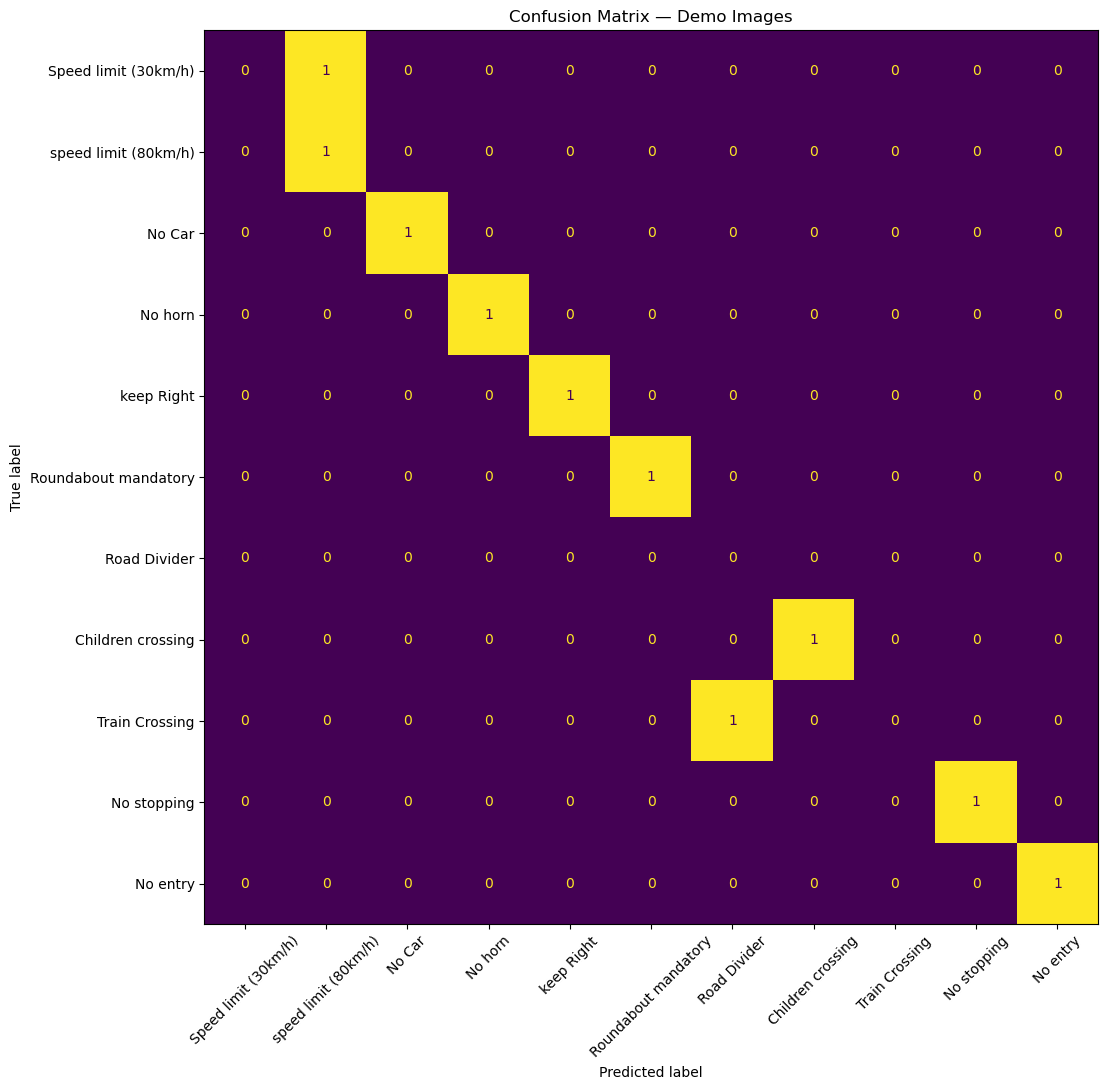

In [112]:
if "true_model_index" in results_df.columns and results_df["true_model_index"].notna().any():
    labeled_results = results_df.dropna(subset=["true_model_index"]).copy()
    labeled_results["true_model_index"] = labeled_results["true_model_index"].astype(int)

    y_true = labeled_results["true_model_index"].values
    y_pred = labeled_results["predicted_model_index"].values

    demo_acc = accuracy_score(y_true, y_pred)
    print(f"Demo accuracy on labeled collected images: {demo_acc:.4f}")

    present_labels = sorted(set(y_true) | set(y_pred))
    present_names = [idx_to_name[i] for i in present_labels]

    print("\nClassification report:")
    print(classification_report(
        y_true,
        y_pred,
        labels=present_labels,
        target_names=present_names,
        zero_division=0,
        digits=4
    ))

    cm = confusion_matrix(y_true, y_pred, labels=present_labels)

    fig, ax = plt.subplots(figsize=(max(6, len(present_labels) * 1.2), max(5, len(present_labels) * 1.0)))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=present_names)
    disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
    plt.title("Confusion Matrix — Demo Images")
    plt.tight_layout()
    plt.show()
else:
    print("No true labels were provided yet.")